In [1]:
from qiskit.circuit import Parameter, QuantumCircuit, QuantumRegister, ClassicalRegister

from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector, Operator
from scipy.optimize import minimize 
from qiskit.circuit.library import QFT
from qiskit import transpile
from qiskit.circuit.library import UnitaryGate

import random
import matplotlib.pyplot as plt
import scipy.linalg as scl
import numpy as np
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeKyiv
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

backend = AerSimulator()
# backend=FakeKyiv()
# sampler = Sampler(backend = backend)
pm = generate_preset_pass_manager(backend=backend,optimization_level=2)

In [2]:


nb_qubits = 4

N = 2**nb_qubits
m = np.zeros((N,N))
for j in range(N):
    if j == N-1:
        break
    else:
       m[j,j+1] = -1 

for j in range(N):
    if j == N-1:
        break
    else:
       m[j+1,j] = -1 
for j in range(N):
   m[j,j] = 2 
m[0] = np.array([1]+ [0]*(N-1))
m[1,0] = 0

b = 0.25*np.array([0,1,1,1,1,1,1,1,1,1,1,1,1,2,0,0])
m

array([[ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., -1.,  2., -1.,  0.,  0.,
         0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.,  0

In [3]:
np.linalg.det(m)



15.999999999999984

In [4]:
def U_b(nb_qubits):
    circ = QuantumCircuit(nb_qubits)
    circ.prepare_state(b)
    return circ
U = U_b(nb_qubits)
b = np.array(Statevector(U_b(nb_qubits)))
b

array([1.52655666e-16+1.80411242e-16j, 2.50000000e-01+2.11636264e-15j,
       2.50000000e-01+1.85962357e-15j, 2.50000000e-01+1.74860126e-15j,
       2.50000000e-01-1.05471187e-15j, 2.50000000e-01-1.30451205e-15j,
       2.50000000e-01-1.49880108e-15j, 2.50000000e-01-1.74860126e-15j,
       2.50000000e-01-2.19269047e-15j, 2.50000000e-01-1.87350135e-15j,
       2.50000000e-01-1.66533454e-15j, 2.50000000e-01-1.41553436e-15j,
       2.50000000e-01+1.41553436e-15j, 5.00000000e-01+2.92821323e-15j,
       0.00000000e+00+8.32667268e-17j, 0.00000000e+00+1.84889275e-32j])

In [5]:
def Hamiltonian(m):
    Ub = np.array(Operator(U_b(nb_qubits)))
    z = np.array([[1,0],
                 [0,-1]])
    I = np.array([[1,0],
                 [0,1]])
    def tensor(i,j,k,l):
        return np.kron(i,np.kron(j,np.kron(k,l)))
    M1 = (np.dot(np.dot(Ub,tensor(z,I,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,z,I,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,z,I)),np.conj(Ub.T))
          + np.dot(np.dot(Ub,tensor(I,I,I,z)),np.conj(Ub.T)))
    M = 0.5*np.dot(np.dot(np.conj(m.T),(tensor(I,I,I,I) - M1/nb_qubits)),m)

    return M
A = Hamiltonian(m)

In [6]:
d,u = np.linalg.eig(A)
d

array([ 1.05409197e+01-9.76789505e-30j,  8.43423780e+00-4.80217939e-30j,
        7.03186296e+00+1.39251751e-29j,  6.13672278e+00-3.58158225e-29j,
        4.82453150e+00+1.81470163e-29j,  4.28987417e+00+2.92451276e-29j,
        2.63515514e+00+1.80148141e-31j,  1.78741871e+00-8.99093850e-30j,
        1.34598333e+00-4.40491932e-30j,  8.02047496e-01+3.30873270e-29j,
        5.85228713e-01+7.08078820e-30j,  3.49301362e-01+3.06709348e-29j,
        1.74677943e-01+3.95042419e-30j,  2.91479977e-02+1.23059217e-29j,
        6.39497219e-03+6.75197540e-30j, -4.68988464e-16-2.52434029e-31j])

In [7]:

U1=scl.expm(2**0*2*np.pi*1j*A) 
U2=scl.expm(2**1*2*np.pi*1j*A) 
U3=scl.expm(2**2*2*np.pi*1j*A) 
U4=scl.expm(2**3*2*np.pi*1j*A) 
U5=scl.expm(2**4*2*np.pi*1j*A) 
U6=scl.expm(2**5*2*np.pi*1j*A) 
U7=scl.expm(2**6*2*np.pi*1j*A) 
U8=scl.expm(2**7*2*np.pi*1j*A)
 
u1gate = UnitaryGate(U1)
u2gate = UnitaryGate(U2)
u3gate=UnitaryGate(U3)
u4gate=UnitaryGate(U4)
u5gate=UnitaryGate(U5)
u6gate=UnitaryGate(U6)
u7gate=UnitaryGate(U7)
u8gate=UnitaryGate(U8)


C_u1gate=u1gate.control()
C_u2gate=u2gate.control()
C_u3gate=u3gate.control()
C_u4gate=u4gate.control()
C_u5gate=u5gate.control()
C_u6gate=u6gate.control()
C_u7gate=u7gate.control()
C_u8gate=u8gate.control()
    

[0.98600511 0.39693224 0.72089462 0.36135681 0.39371065 0.64181
 0.54087274 0.15596923 0.42179262 0.51678456 0.22916061 0.66736852
 0.06578829 0.18780831 0.90302615 0.61387919 0.07571959 0.78783502
 0.80335611 0.8656569  0.36694413 0.56447486 0.49885888 0.85887889
 0.21442787 0.8140991  0.17225246 0.09192131 0.48053858 0.1978216
 0.83790844 0.34412944 0.3005543  0.33562501 0.44945517 0.06735328]


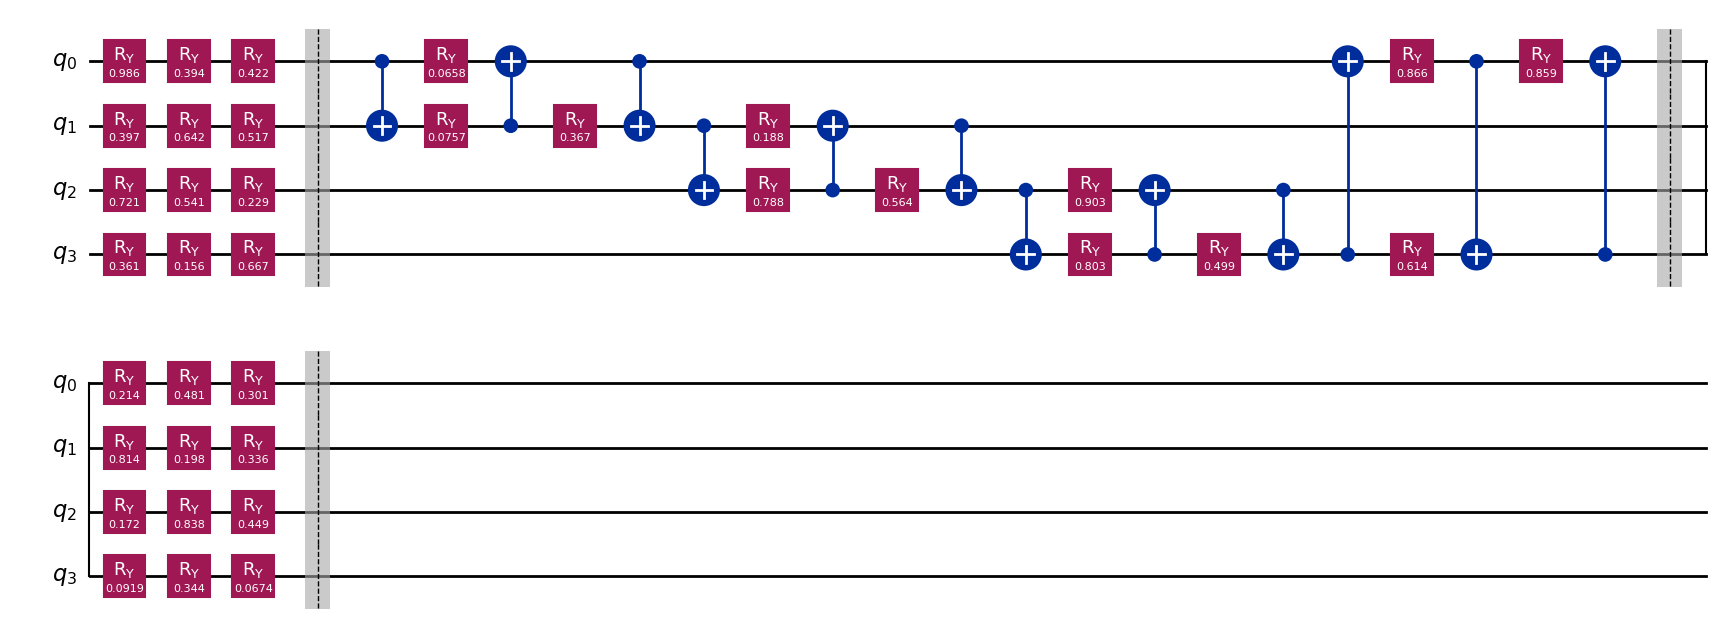

In [8]:
def ansatz(Parameters):
    qc = QuantumCircuit(N)
    for d in range(depth):
        param1=Parameters[d*9*N:(d+1)*(9*N)]
        for q in range(N):
            qc.ry(param1[q],qubits[q])
            qc.ry(param1[q+N],qubits[q])
            qc.ry(param1[q+2*N],qubits[q])
        qc.barrier()
        for q in range(N):
            qc.cx(qubits[q], qubits[(q+1)% N])
            qc.ry(param1[q+3*N],qubits[q])
            qc.ry(param1[q+4*N],qubits[(q+1)% N])
            qc.cx(qubits[(q+1)% N], qubits[q])
            qc.ry(param1[q+5*N],qubits[(q+1)% N])
            qc.cx(qubits[q], qubits[(q+1)% N])
        qc.barrier()
        if d==depth-1:
            for q in range(N):
                qc.ry(param1[q+6*N],qubits[q])
                qc.ry(param1[q+7*N],qubits[q])
                qc.ry(param1[q+8*N],qubits[q])
        qc.barrier()
    
    return qc

nb_qubits=4
depth=1
qubits=list(range(nb_qubits))
N=len(qubits)
nb_params=int(9*N*depth)
# Parameters = np.array([random.random() for _ in range(0, nb_params)])

Parameters = np.array([0.98600511, 0.39693224, 0.72089462, 0.36135681, 0.39371065, 0.64181,
 0.54087274, 0.15596923, 0.42179262, 0.51678456, 0.22916061, 0.66736852,
 0.06578829, 0.18780831, 0.90302615, 0.61387919, 0.07571959, 0.78783502,
 0.80335611, 0.8656569,  0.36694413, 0.56447486, 0.49885888, 0.85887889,
 0.21442787, 0.8140991,  0.17225246, 0.09192131, 0.48053858, 0.1978216,
 0.83790844, 0.34412944, 0.3005543,  0.33562501, 0.44945517, 0.06735328])
print(Parameters)
ansatz(Parameters).draw("mpl")

In [10]:

def circ(parameters):
    x=QuantumRegister(12)
    c=ClassicalRegister(8)
    circuit = QuantumCircuit(x,c)

    circuit=circuit.compose(ansatz(parameters),x[8:12])
    circuit.h(x[0:8]) 
    circuit.append(C_u1gate, [x[0],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u2gate, [x[1],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u3gate, [x[2],x[8],x[9],x[10],x[11]])    
    circuit.append(C_u4gate, [x[3],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u5gate, [x[4],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u6gate, [x[5],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u7gate, [x[6],x[8],x[9],x[10],x[11]]) 
    circuit.append(C_u8gate, [x[7],x[8],x[9],x[10],x[11]]) 
    circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True, 
                   inverse=True, insert_barriers=False, name='qft')
    circuit.measure(x[0:8],c)       
    return circuit

/tmp/ipykernel_1770095/3672667775.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True,


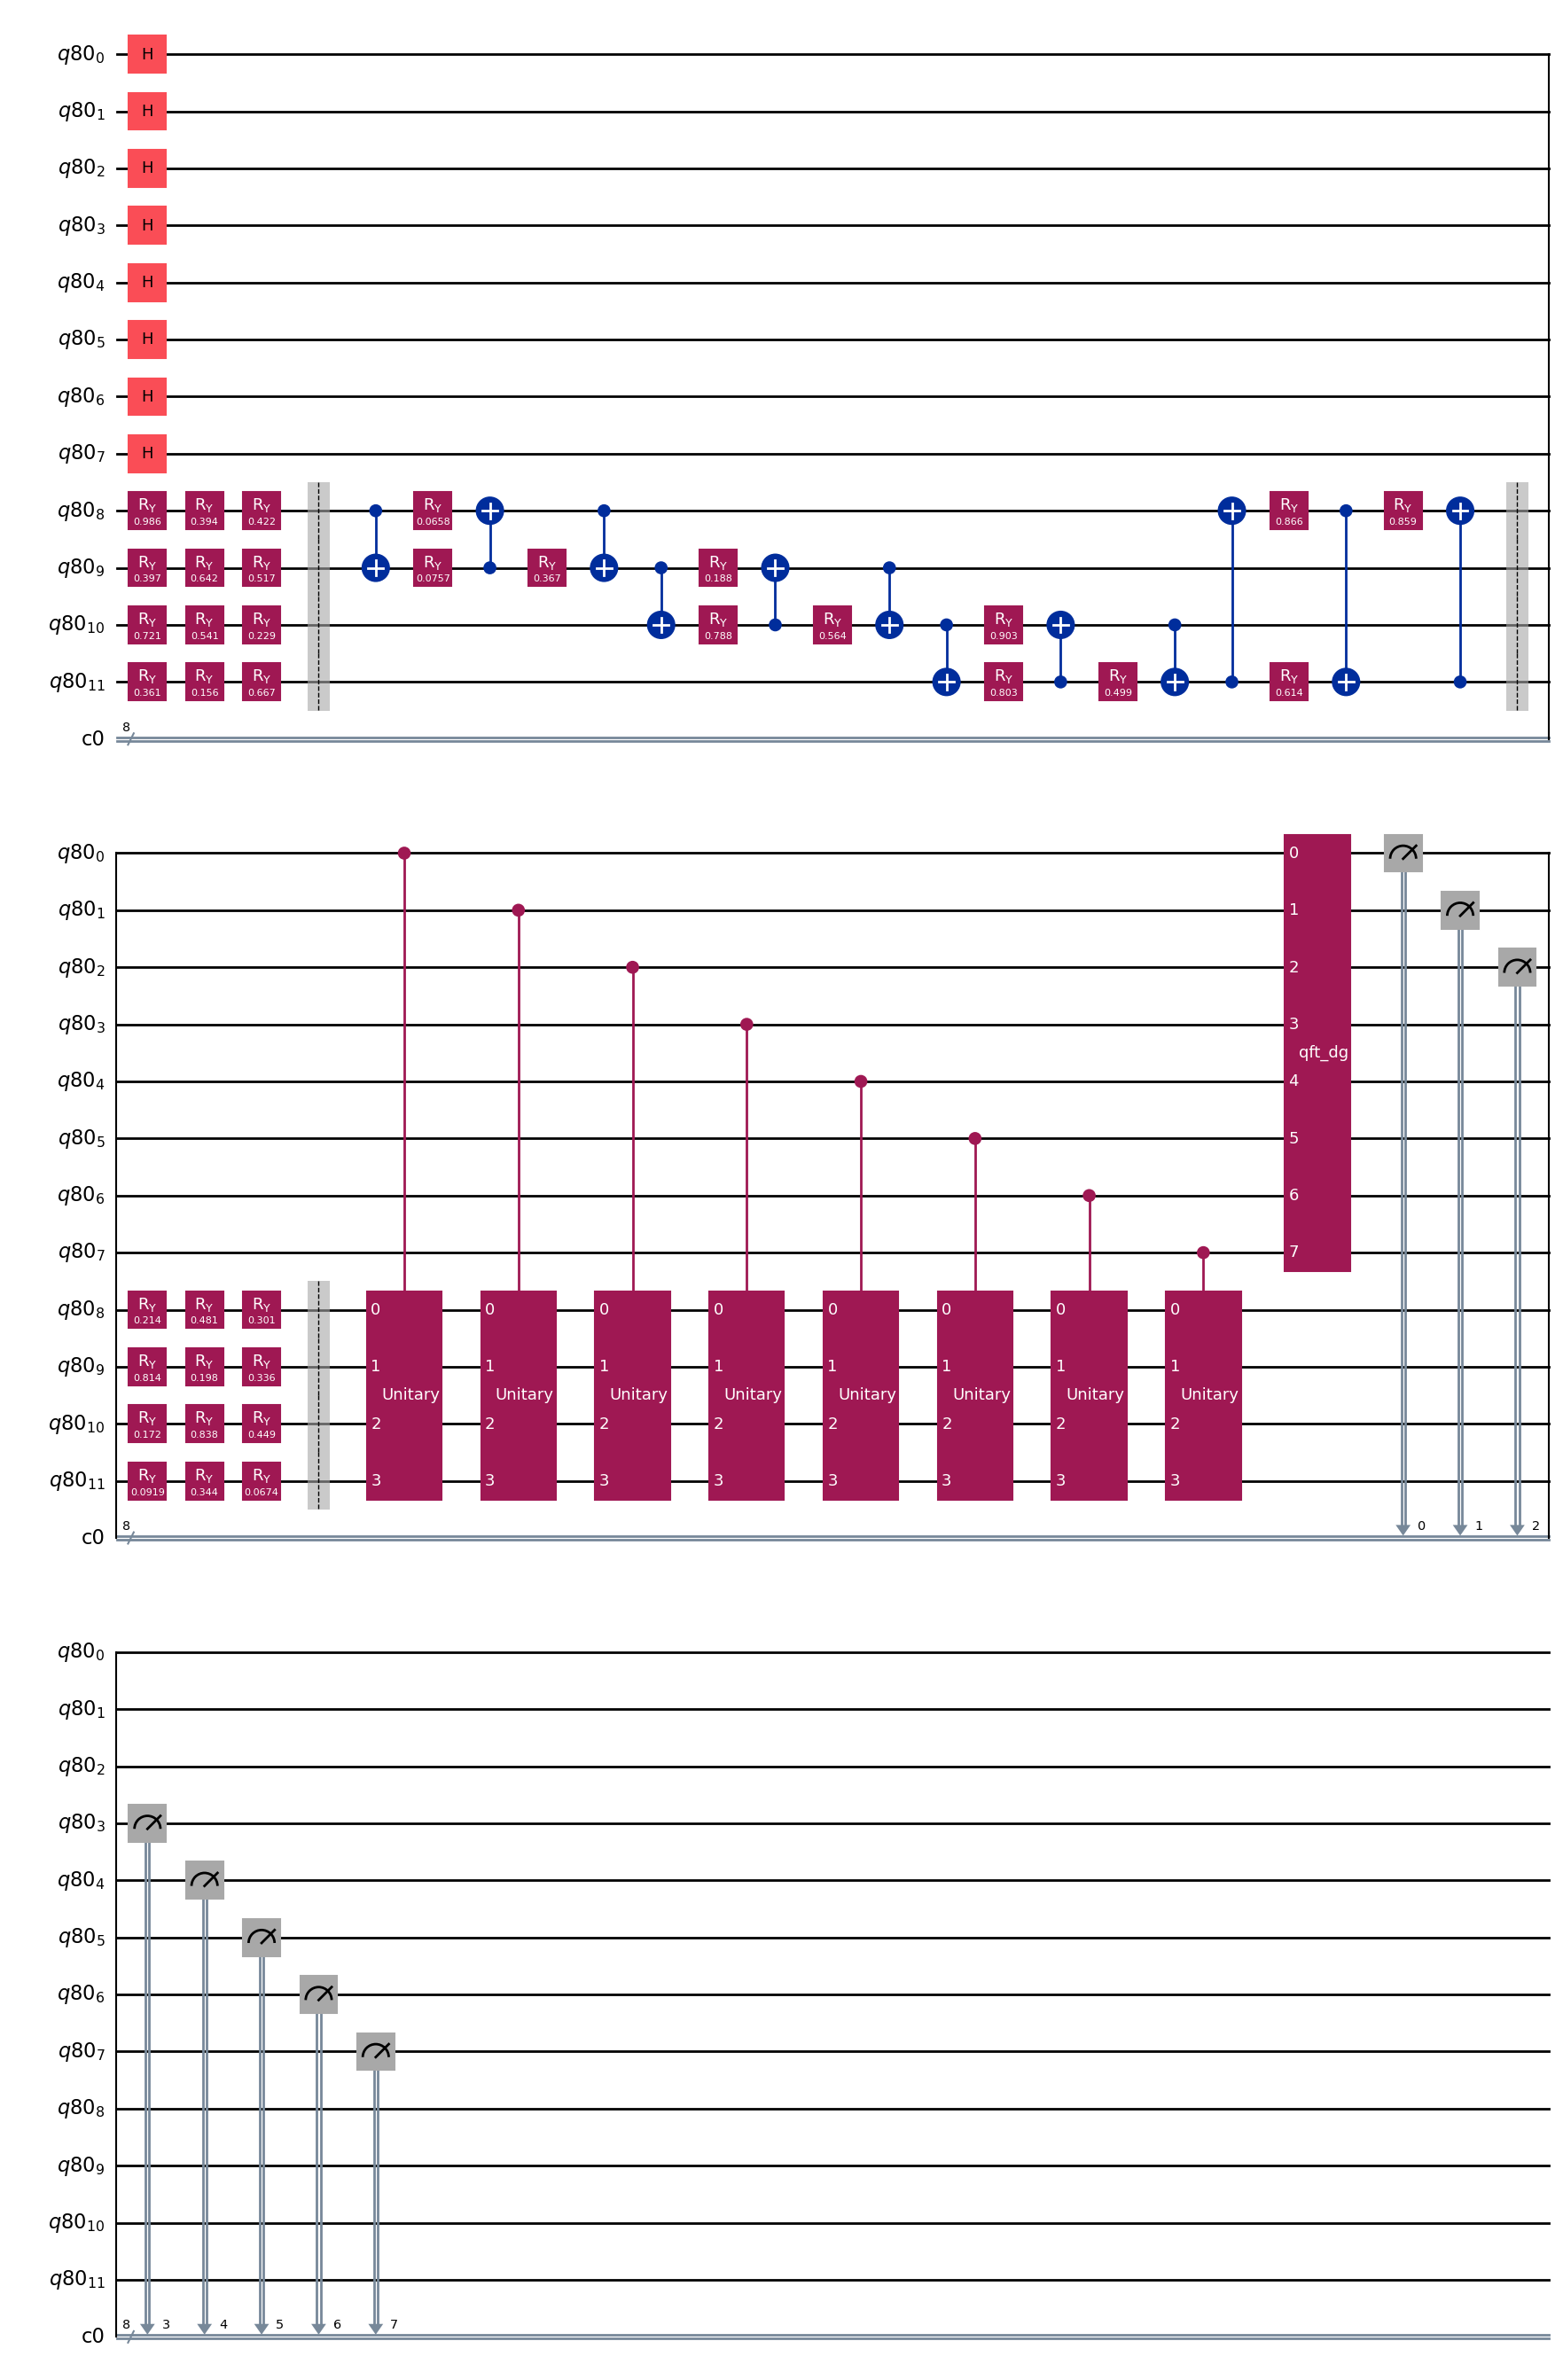

In [11]:
circ(Parameters).draw("mpl") 

In [12]:
shots = 100000
def cost(Parameters):
    job = backend.run(pm.run(circ(Parameters)),shots = shots).result()
    result = job.get_counts(0)
    if '00000000'not in result: 
        res = 1
    else:
        res = 1 - result['00000000']/shots
    return res
# cost(parameters)


In [13]:
from scipy.optimize import minimize
def save(Parameters):
    global Cost,Params
    Cost.append(cost(Parameters))
    Params.append(Parameters)
    print(cost(Parameters))
Cost = []
Params = []
minimize(cost, x0 = Parameters,callback = save, method="cobyla",
              options = {'maxiter':6000})
    
    

/tmp/ipykernel_1770095/3672667775.py:16: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  circuit &= QFT(num_qubits=8, approximation_degree=0, do_swaps=True,


0.8688400000000001
0.94628
0.91452
0.82011
0.86342
0.92004
0.9256
0.8616699999999999
0.86313
0.92098
0.92767
0.8618
0.86324
0.8664499999999999
0.80053
0.8457600000000001
0.79408
0.79701
0.9754
0.94691
0.8989199999999999
0.93869
0.89186
0.86307
0.75198
0.94511
0.98057
0.92024
0.82375
0.94551
0.97989
0.9216
0.82428
0.94382
0.98151
0.92079
0.58592
0.47477
0.53156
0.39681
0.55691
0.47024
0.41825999999999997
0.52742
0.42608
0.5338
0.51034
0.43325
0.34707
0.236
0.23255000000000003
0.71679
0.22221000000000002
0.42742
0.27148000000000005
0.24724999999999997
0.27919000000000005
0.38310999999999995
0.29277
0.48854
0.20391000000000004
0.28771
0.20359000000000005
0.31927000000000005
0.20453
0.5984499999999999
0.31845999999999997
0.27090000000000003
0.20496999999999999
0.27971999999999997
0.20679000000000003
0.41864999999999997
0.33229
0.89389
0.22751999999999994
0.44688000000000005
0.19350999999999996
0.26591
0.23470999999999997
0.37333000000000005
0.29023
0.22955000000000003
0.23119999999999996
0

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.009929999999999994
       x: [ 9.284e-01  1.266e+00 ... -3.819e-01 -4.255e-01]
    nfev: 533
   maxcv: 0.0

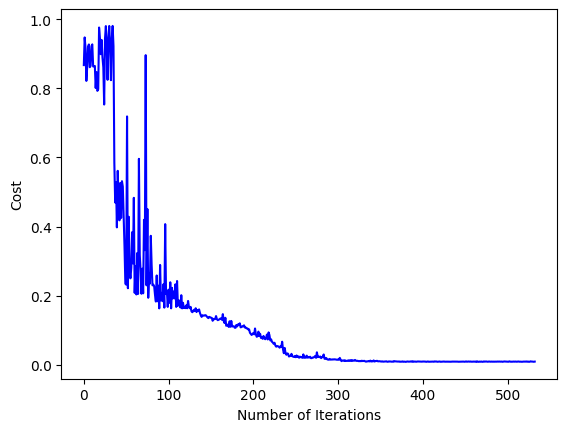

In [14]:
plt.plot(range(len(Cost)), Cost,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.xlabel('Number of Iterations')
plt.ylabel('Cost')
plt.show()


In [15]:
x_exact = np.linalg.solve(m,b)
x_exact = x_exact/np.linalg.norm(x_exact)

In [16]:
e = []
F = []
norm_e = []
for k in range(len(Params)):
    state = np.array(Statevector(ansatz(Params[k])))
    psi = np.dot(m,state)
    Psi = psi/np.linalg.norm(psi)
    norm = np.dot(Psi,b)
    e.append(x_exact - state/norm)
    # f = abs(np.dot(Psi,b))**2
    f = abs(np.dot(state,x_exact))**2
    F.append(f)

for v in e:
    norm_e.append(float(np.linalg.norm(v)))

Text(0.5, 0, 'Iteration')

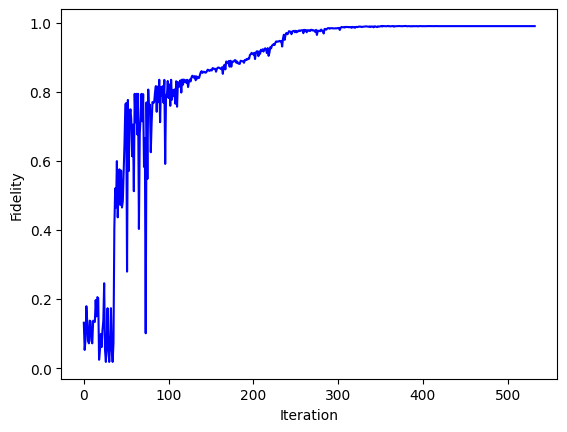

In [17]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(F)),F,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Fidelity')
plt.xlabel('Iteration')


In [18]:
norm_e[np.argmax(F)]

3.6668207099239893

In [19]:
ef = abs(np.array(e[np.argmax(F)]))
ef

array([0.02238483, 0.41782308, 0.49248676, 0.87775482, 1.0233427 ,
       0.84452066, 1.14939262, 1.14177188, 1.10522939, 1.31198638,
       1.3702571 , 0.96072796, 1.0019024 , 0.84457069, 0.57427187,
       0.28630238])

Text(0.5, 0, 'Iteration')

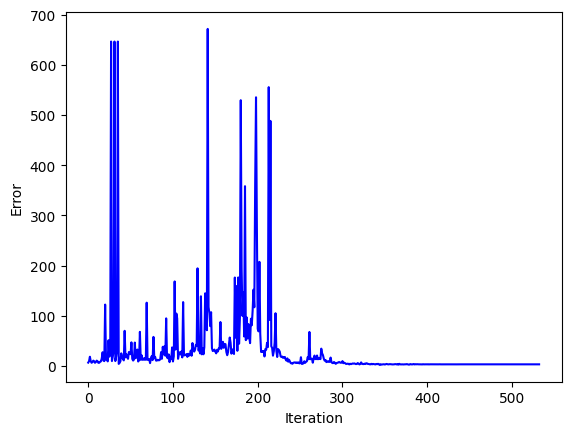

In [20]:
# plt.scatter(range(len(F)),F)
plt.plot(range(len(norm_e)),norm_e,'b')
# plt.axis([0, 100, 0, 0.0007])
plt.ylabel('Error')
plt.xlabel('Iteration')

In [21]:
X_opt  = np.array(Statevector(ansatz(Params[-1])))
psi = m@X_opt
psi = psi/np.linalg.norm(psi)

In [22]:
abs(np.array(e[-1]))

array([0.00282194, 0.39537392, 0.45884072, 0.7993802 , 0.88912254,
       0.71326301, 1.0081348 , 0.97216591, 0.93358857, 1.13542329,
       1.17736757, 0.83736662, 0.81811904, 0.71499732, 0.45633101,
       0.23799117])

In [23]:
X_opt

array([ 0.00068005+0.j, -0.11466124+0.j, -0.14675269+0.j, -0.24303126+0.j,
       -0.27628659+0.j, -0.24295092+0.j, -0.32047179+0.j, -0.31567988+0.j,
       -0.30767525+0.j, -0.35502297+0.j, -0.36125488+0.j, -0.27285841+0.j,
       -0.25917559+0.j, -0.22269599+0.j, -0.14356377+0.j, -0.07414976+0.j])

In [24]:
print(F)

[0.13169134611453567, 0.05292081518476671, 0.0827801639076759, 0.1795223886028094, 0.13543193219118665, 0.079169918976983, 0.07192987357754366, 0.13757356031629814, 0.13543193219118677, 0.079169918976983, 0.07192987357754368, 0.137573560316298, 0.13523228885824168, 0.13403153548983052, 0.19723603623423525, 0.15000149102770183, 0.2057499556705898, 0.20207579881551443, 0.02439924169884196, 0.052181359404149474, 0.09902619207475498, 0.061050804714549455, 0.10954083913434466, 0.13730674251962835, 0.24593310194923396, 0.053161970563634, 0.018184244490135587, 0.07412436664750667, 0.17373768490666933, 0.05316197056363406, 0.018184244490135566, 0.0741243666475066, 0.17373768490666927, 0.053161970563634045, 0.018184244490135573, 0.0741243666475066, 0.4053891880655144, 0.5204974309198448, 0.46506371941835534, 0.5995537878325939, 0.4367105266260089, 0.5242940011625397, 0.5756708956108816, 0.472943362825369, 0.5719895258494754, 0.4652142897941244, 0.48311393339339237, 0.567018463498822, 0.65186975

In [25]:
print(norm_e)

[6.581470071223015, 9.385788918370675, 18.312260310200738, 9.459588814327489, 6.20505862656674, 7.6724528247144725, 10.566087858276434, 9.36176291645654, 6.205058626566745, 7.67245282471447, 10.566087858276434, 9.361762916456533, 6.197111330241481, 6.24777921874538, 8.246495747855308, 8.967439164626583, 15.057953615360146, 27.276450892515722, 10.579643597209706, 9.583686539297359, 122.22930665642306, 12.356004384454767, 18.2121503649399, 9.086315776054887, 51.16734239305352, 18.482361599081134, 30.831081179172834, 646.4445388030733, 9.693035252919953, 18.482361599081152, 30.831081179172806, 646.4445388030908, 9.693035252919955, 18.482361599081155, 30.83108117917278, 646.4445388030849, 4.075850563387472, 5.92447013394913, 9.214962874394898, 25.01735389728047, 17.536743395373826, 14.459067012430978, 10.989772122730294, 69.9512879905209, 17.078271335253024, 23.570291592494794, 17.111562558586293, 14.175188752849497, 27.728200240033516, 23.711023519135885, 23.42546707983752, 46.97255498960

In [26]:
min(norm_e)

1.9902508596605661

In [27]:
1-max(F)

0.009082688559267083